In [28]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")


In [29]:

# DATA LOADING

BASE = "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data"
df   = pd.read_csv(f"{BASE}/Country-data.csv")
dd   = pd.read_csv(f"{BASE}/data-dictionary.csv")

print(f"Dataset: {df.shape[0]} countries, {df.shape[1]} features\n")
display(dd.set_index("Column Name"))
display(df.sample(8, random_state=1))


Dataset: 167 countries, 10 features



,Description
Column Name,
country,Name of the country
child_mort,Death of children under 5 years of age per 100...
exports,Exports of goods and services per capita. Give...
health,Total health spending per capita. Given as %ag...
imports,Imports of goods and services per capita. Give...
Income,Net income per person
Inflation,The measurement of the annual growth rate of t...
life_expec,The average number of years a new born child w...
total_fer,The number of children that would be born to e...


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
44,Denmark,4.1,50.5,11.40,43.6,44000,3.22,79.5,1.87,58000
47,Egypt,29.1,21.3,4.66,26.6,9860,10.10,70.5,3.19,2600
143,Suriname,24.1,52.5,7.01,38.4,14200,7.20,70.3,2.52,8300
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662
147,Tanzania,71.9,18.7,6.01,29.1,2090,9.25,59.3,5.43,702
11,Bahrain,8.6,69.5,4.97,50.9,41100,7.44,76.0,2.16,20700
78,Jordan,21.1,48.3,8.04,69.0,9470,8.43,75.8,3.66,3680
35,Colombia,18.6,15.9,7.59,17.8,10900,3.86,76.4,2.01,6250


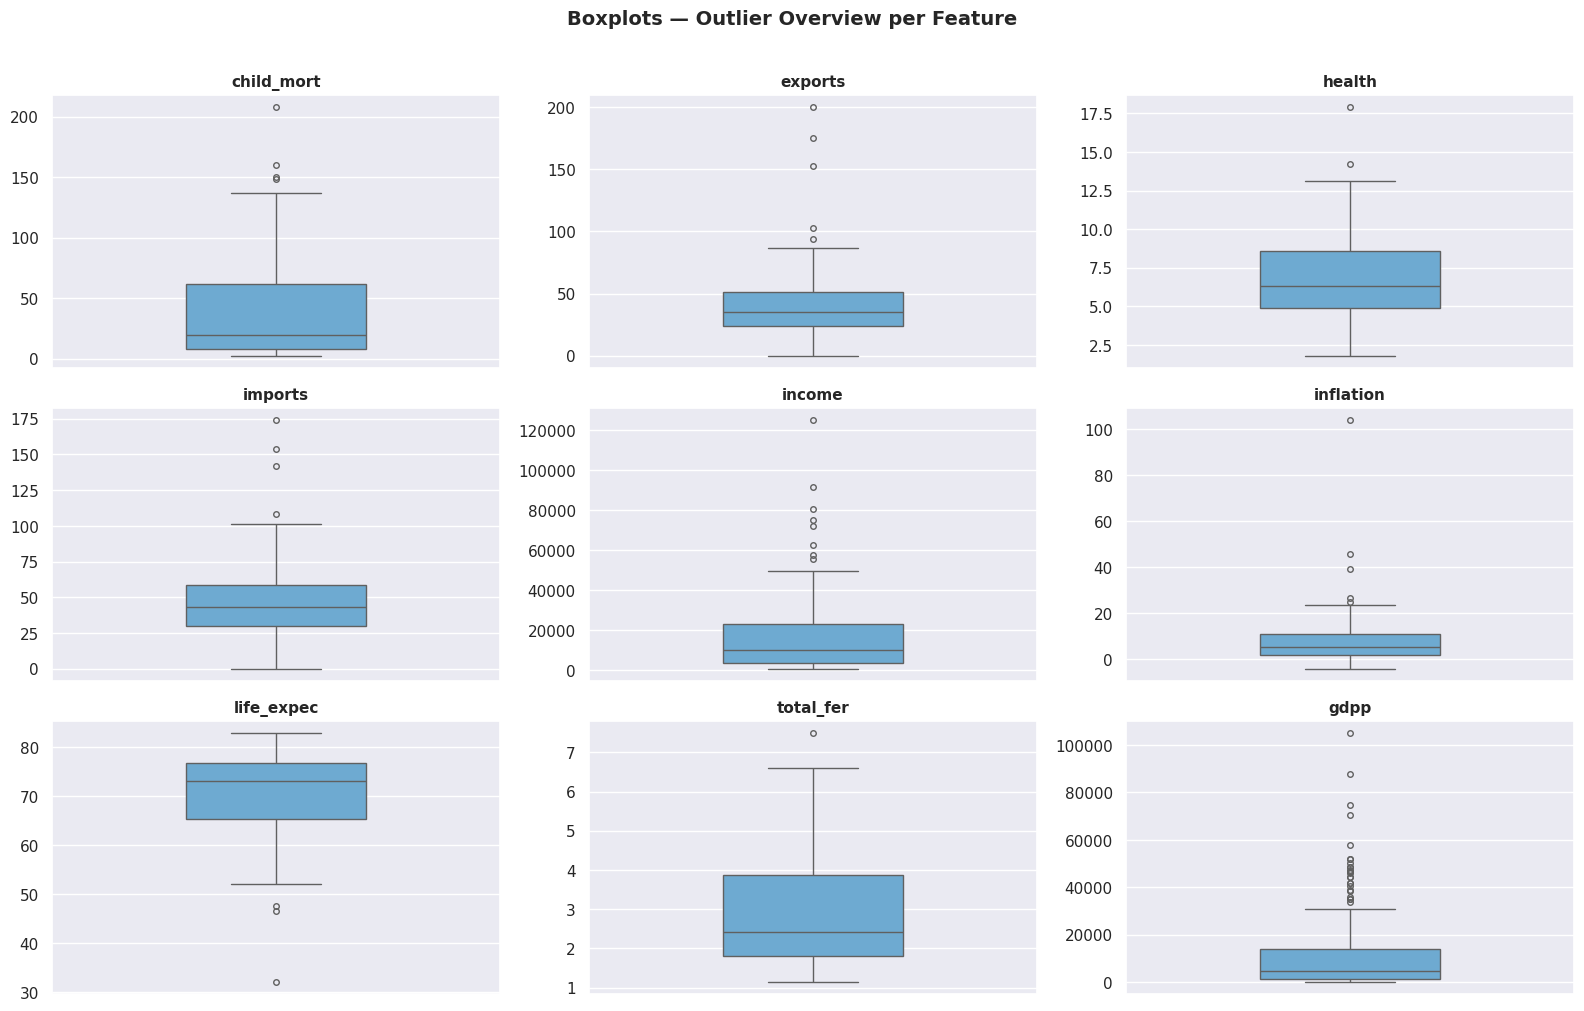

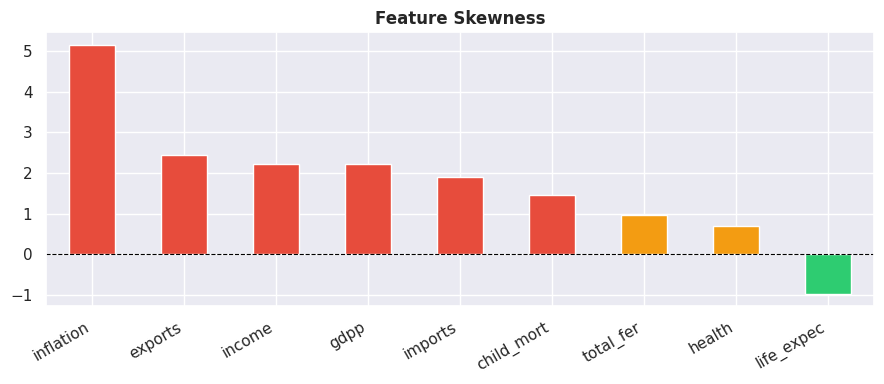

Red = highly skewed (>1), Orange = moderate, Green = low


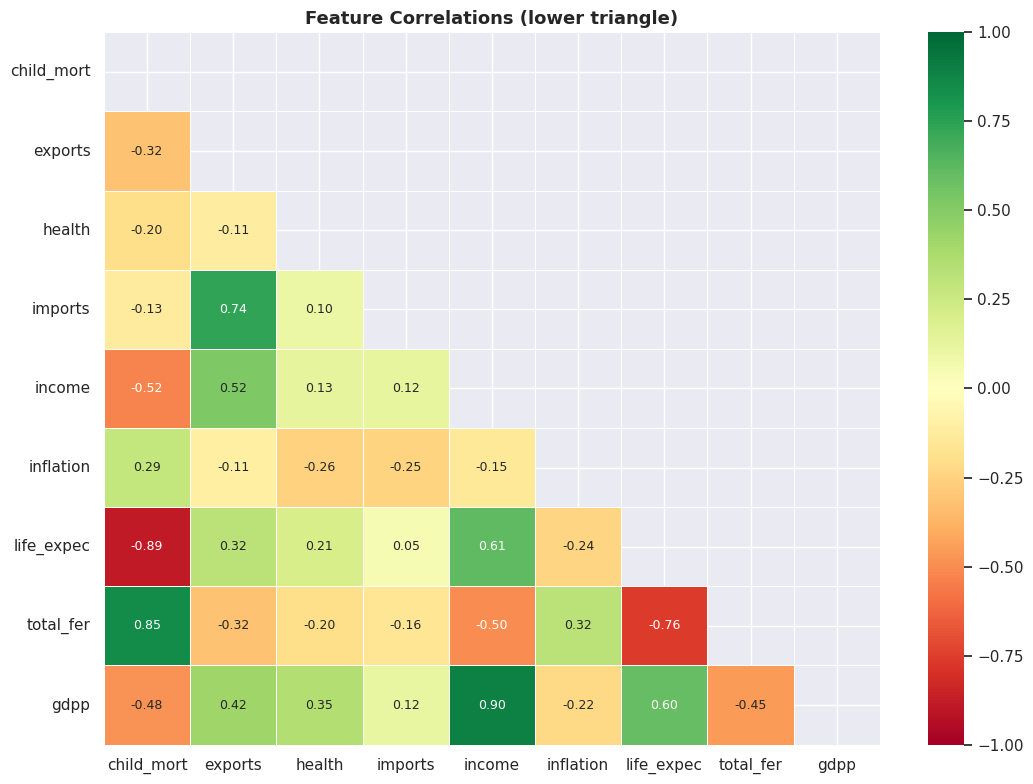

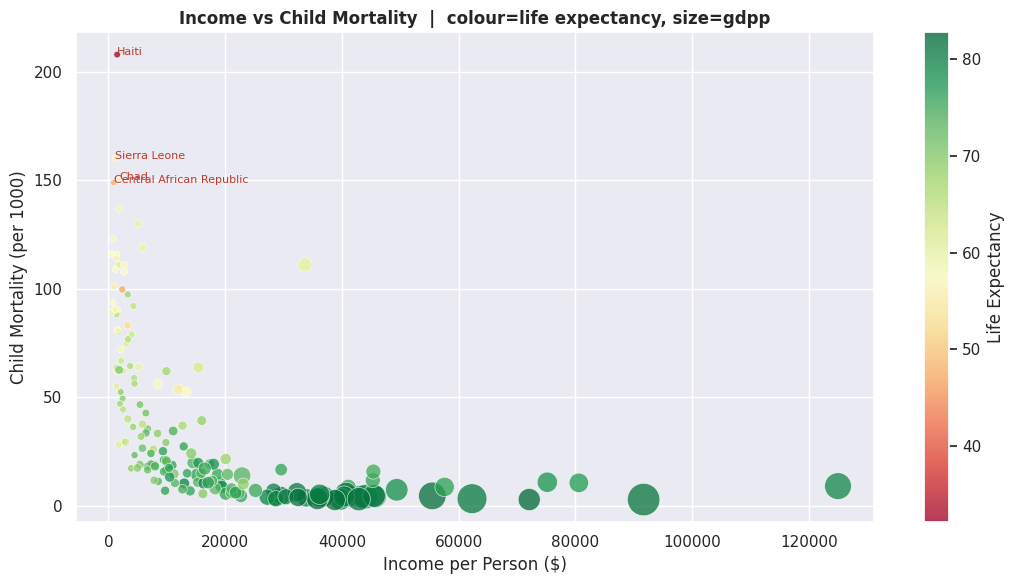

In [30]:
#section 2


FEATS = ['child_mort','exports','health','imports',
         'income','inflation','life_expec','total_fer','gdpp']

# --- 2a. Box plots (spot outliers better than histograms) ---
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), FEATS):
    sns.boxplot(y=df[col], ax=ax, color='#5dade2', width=0.4, flierprops=dict(marker='o', markersize=4))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel("")
fig.suptitle("Boxplots — Outlier Overview per Feature", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- 2b. Skewness bar ---
skew = df[FEATS].skew().sort_values(ascending=False)
plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if v > 1 else '#f39c12' if v > 0.5 else '#2ecc71' for v in skew]
skew.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Feature Skewness", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print("Red = highly skewed (>1), Orange = moderate, Green = low")

# --- 2c. Heatmap with cluster-friendly diverging palette ---
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(df[FEATS].corr(), dtype=bool))
sns.heatmap(df[FEATS].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 9})
plt.title("Feature Correlations (lower triangle)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 2d. Scatter: income vs child_mort (size = gdpp) ---
plt.figure(figsize=(11, 6))
sc = plt.scatter(df['income'], df['child_mort'],
                 c=df['life_expec'], cmap='RdYlGn',
                 s=df['gdpp']/200 + 20, alpha=0.75, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, label='Life Expectancy')
plt.xlabel("Income per Person ($)")
plt.ylabel("Child Mortality (per 1000)")
plt.title("Income vs Child Mortality  |  colour=life expectancy, size=gdpp", fontweight='bold')
# annotate extreme outliers
for _, row in df[df['child_mort'] > 140].iterrows():
    plt.annotate(row['country'], (row['income'], row['child_mort']),
                 fontsize=8, ha='left', color='#c0392b')
plt.tight_layout()
plt.show()



Components needed for 85% variance: 4


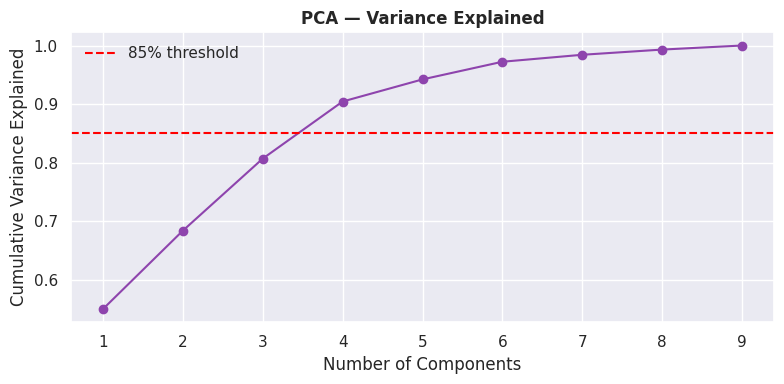

2-component PCA variance: 68.4%


In [31]:
#Preprossing

# MinMaxScaler instead of Standard (keeps relative distances, works well for clustering)
X      = df[FEATS].values
scaler = MinMaxScaler()
X_sc   = scaler.fit_transform(X)

# PCA — keep enough for 85% variance
pca_full = PCA(random_state=0).fit(X_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = np.argmax(cum_var >= 0.85) + 1
print(f"\nComponents needed for 85% variance: {n_comp}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='#8e44ad')
plt.axhline(0.85, color='red', linestyle='--', label='85% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA — Variance Explained", fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

pca2 = PCA(n_components=2, random_state=0)
X_2d = pca2.fit_transform(X_sc)
print(f"2-component PCA variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%")


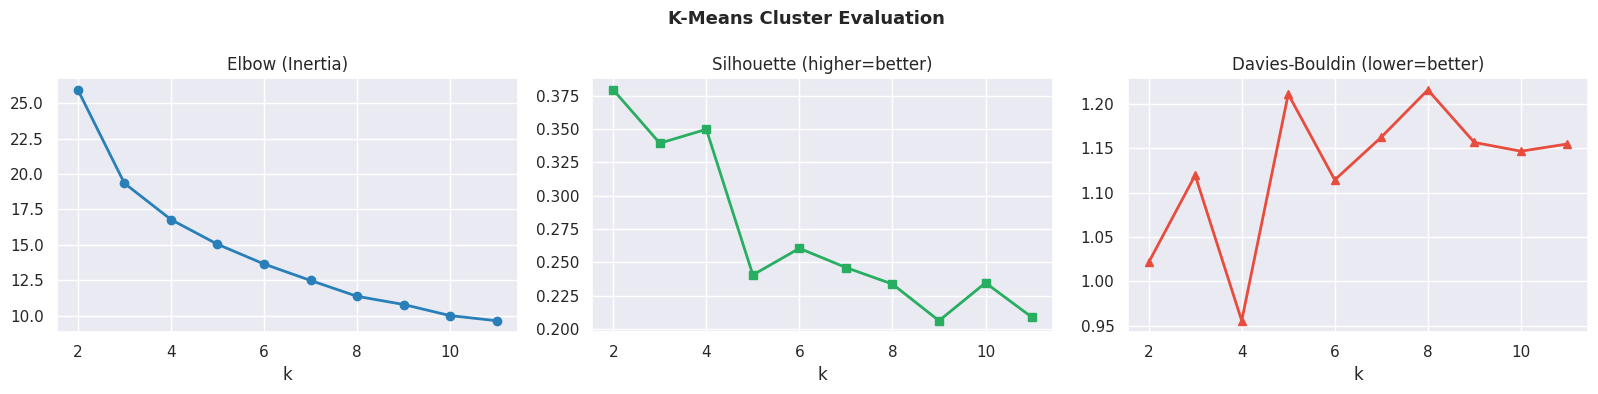

,k,inertia,silhouette,davies
0,2,25.940,0.379,1.021
1,3,19.345,0.339,1.120
2,4,16.781,0.350,0.956
3,5,15.036,0.240,1.211
4,6,13.642,0.260,1.114
5,7,12.479,0.246,1.162
6,8,11.362,0.234,1.216
7,9,10.782,0.206,1.156
8,10,9.997,0.235,1.147
9,11,9.637,0.209,1.155


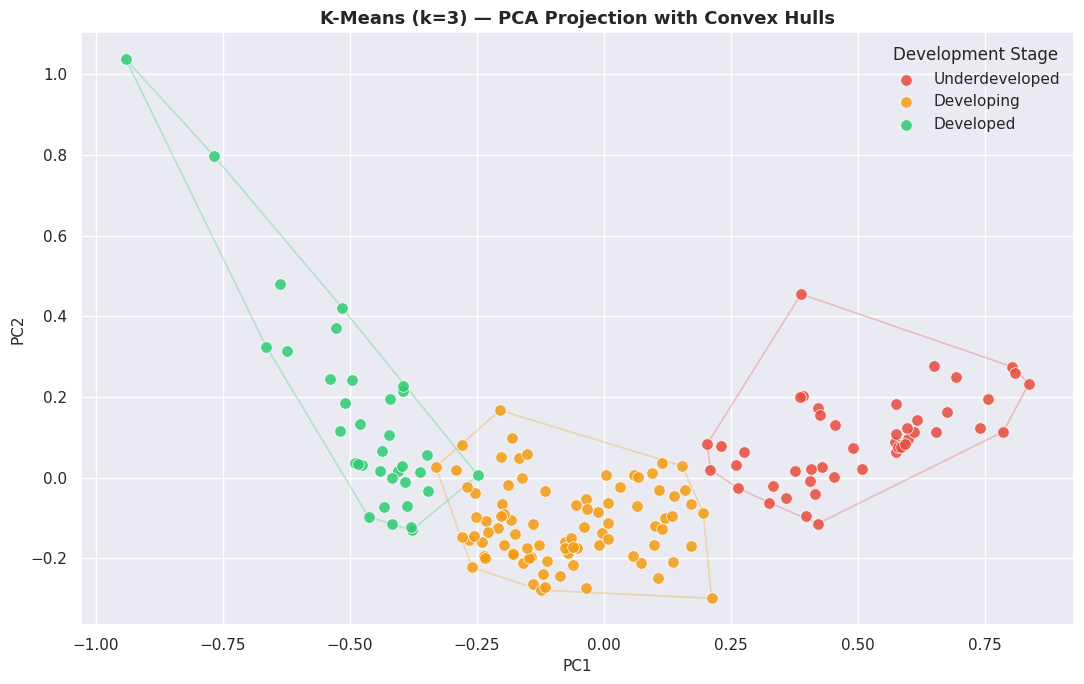

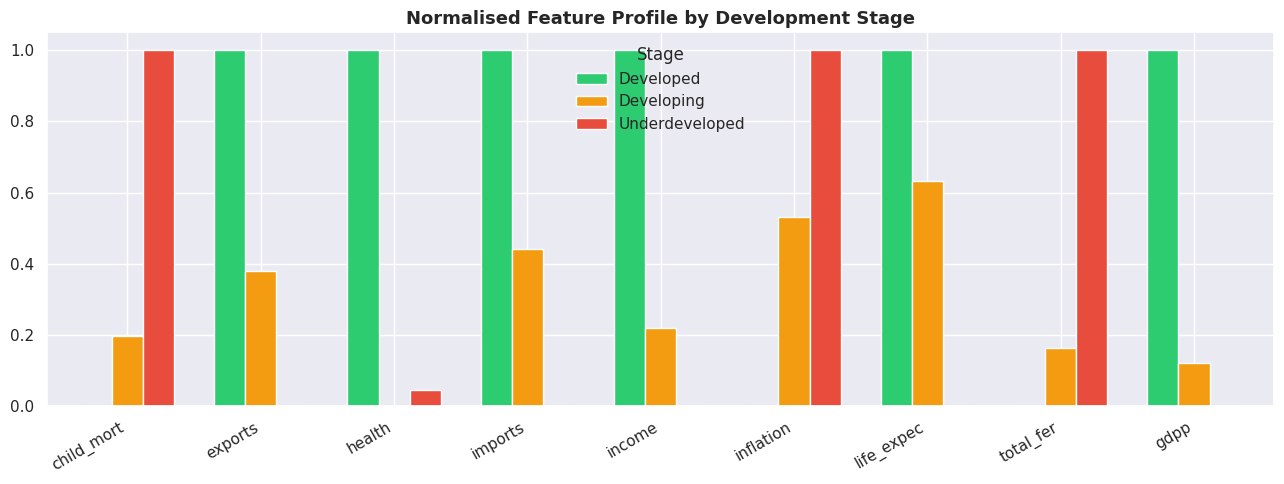


Cluster Profile (raw means):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
stage,,,,,,,,,
Developed,4.9,58.4,8.9,51.5,45802.9,2.5,80.2,1.7,43117.1
Developing,22.4,40.4,6.2,46.9,12770.8,7.6,72.6,2.3,6719.8
Underdeveloped,93.3,29.3,6.3,43.3,3516.8,12.1,59.4,5.1,1695.9



Country counts:
stage
Developing        86
Underdeveloped    46
Developed         35

Underdeveloped (46): Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea...

Developing (86): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia...

Developed (35): Australia, Austria, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland...


In [32]:
#K Map

results = []
for k in range(2, 12):
    km     = KMeans(n_clusters=k, random_state=0, n_init=15, max_iter=500)
    labels = km.fit_predict(X_sc)
    results.append({
        'k':          k,
        'inertia':    km.inertia_,
        'silhouette': silhouette_score(X_sc, labels),
        'davies':     davies_bouldin_score(X_sc, labels)
    })
res = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(res.k, res.inertia,    'o-', color='#2980b9', linewidth=2); axes[0].set_title("Elbow (Inertia)")
axes[1].plot(res.k, res.silhouette, 's-', color='#27ae60', linewidth=2); axes[1].set_title("Silhouette (higher=better)")
axes[2].plot(res.k, res.davies,     '^-', color='#e74c3c', linewidth=2); axes[2].set_title("Davies-Bouldin (lower=better)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(True)
plt.suptitle("K-Means Cluster Evaluation", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

display(res.round(3))

# --- Final model k=3 ---
K = 3
km3 = KMeans(n_clusters=K, random_state=0, n_init=15, max_iter=500)
df['cluster'] = km3.fit_predict(X_sc)

# Auto-label: rank by mean child_mort descending
rank = df.groupby('cluster')['child_mort'].mean().sort_values(ascending=False)
stage_map = {rank.index[0]: 'Underdeveloped', rank.index[1]: 'Developing', rank.index[2]: 'Developed'}
df['stage'] = df['cluster'].map(stage_map)

# PCA scatter with convex hull boundaries
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull

COLORS = {'Underdeveloped': '#e74c3c', 'Developing': '#f39c12', 'Developed': '#2ecc71'}
fig, ax = plt.subplots(figsize=(11, 7))
for stage, color in COLORS.items():
    pts  = X_2d[df['stage'] == stage]
    ax.scatter(pts[:,0], pts[:,1], color=color, s=70, alpha=0.85,
               edgecolors='white', linewidth=0.6, label=stage, zorder=3)
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        for simplex in hull.simplices:
            ax.plot(pts[simplex,0], pts[simplex,1], color=color, alpha=0.3, linewidth=1.2)
ax.set_xlabel("PC1", fontsize=11); ax.set_ylabel("PC2", fontsize=11)
ax.set_title("K-Means (k=3) — PCA Projection with Convex Hulls", fontsize=13, fontweight='bold')
ax.legend(title="Development Stage"); plt.tight_layout(); plt.show()

# Cluster profile radar-style bar
profile = df.groupby('stage')[FEATS].mean()
p_norm  = (profile - profile.min()) / (profile.max() - profile.min())
p_norm.T.plot(kind='bar', figsize=(13, 5),
              color=[COLORS[s] for s in p_norm.index],
              edgecolor='white', width=0.7)
plt.title("Normalised Feature Profile by Development Stage", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.legend(title="Stage")
plt.tight_layout(); plt.show()

print("\nCluster Profile (raw means):")
display(profile.round(1))
print("\nCountry counts:")
print(df['stage'].value_counts().to_string())

# Sample countries
for s in ['Underdeveloped','Developing','Developed']:
    ctries = df[df['stage']==s]['country'].tolist()
    print(f"\n{s} ({len(ctries)}): {', '.join(ctries[:14])}{'...' if len(ctries)>14 else ''}")



DBSCAN  →  clusters: 1   |   outliers: 0
Outlier countries: 


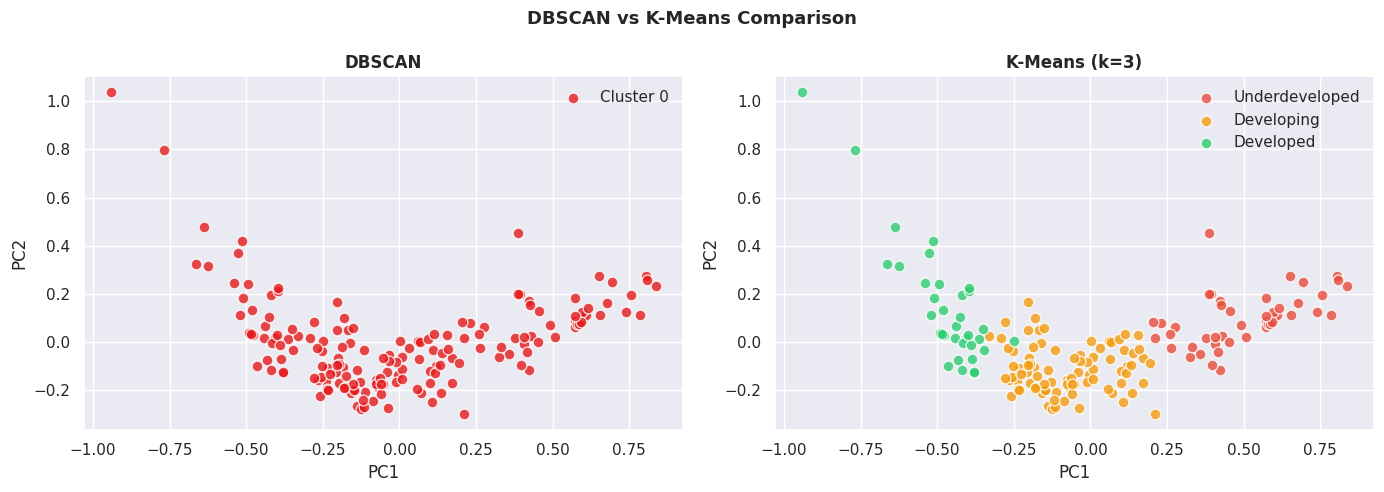

In [33]:
#DBSCAN

db     = DBSCAN(eps=1.8, min_samples=4)
df['dbscan'] = db.fit_predict(X_sc)

n_db    = len(set(df['dbscan'])) - (1 if -1 in df['dbscan'].values else 0)
n_noise = (df['dbscan']==-1).sum()
print(f"\nDBSCAN  →  clusters: {n_db}   |   outliers: {n_noise}")
print("Outlier countries:", ', '.join(df[df['dbscan']==-1]['country'].tolist()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# left: DBSCAN
cmap = plt.get_cmap('Set1')
for lbl in sorted(df['dbscan'].unique()):
    m   = df['dbscan']==lbl
    col = '#aaaaaa' if lbl==-1 else cmap(lbl)
    axes[0].scatter(X_2d[m,0], X_2d[m,1], color=col, s=60, alpha=0.8,
                    edgecolors='white', label='Outlier' if lbl==-1 else f'Cluster {lbl}')
axes[0].set_title("DBSCAN", fontweight='bold')
axes[0].legend()

# right: K-Means side by side
for stage, color in COLORS.items():
    m = df['stage']==stage
    axes[1].scatter(X_2d[m,0], X_2d[m,1], color=color, s=60,
                    alpha=0.8, edgecolors='white', label=stage)
axes[1].set_title("K-Means (k=3)", fontweight='bold')
axes[1].legend()

for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle("DBSCAN vs K-Means Comparison", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



Random Forest  (CV acc: 0.970 ± 0.033)
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       1.00      0.82      0.90        11
    Developing       0.92      1.00      0.96        22

      accuracy                           0.95        42
     macro avg       0.97      0.94      0.95        42
  weighted avg       0.96      0.95      0.95        42


XGBoost  (CV acc: 0.964 ± 0.035)
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       1.00      0.73      0.84        11
    Developing       0.88      1.00      0.94        22

      accuracy                           0.93        42
     macro avg       0.96      0.91      0.93        42
  weighted avg       0.94      0.93      0.93        42


Gradient Boosting  (CV acc: 0.958 ± 0.041)
                precision    recall  f1-score   support

     Developed       1.00      1.00

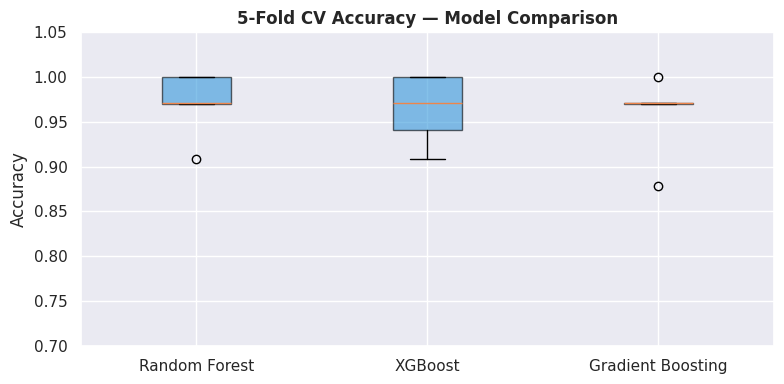

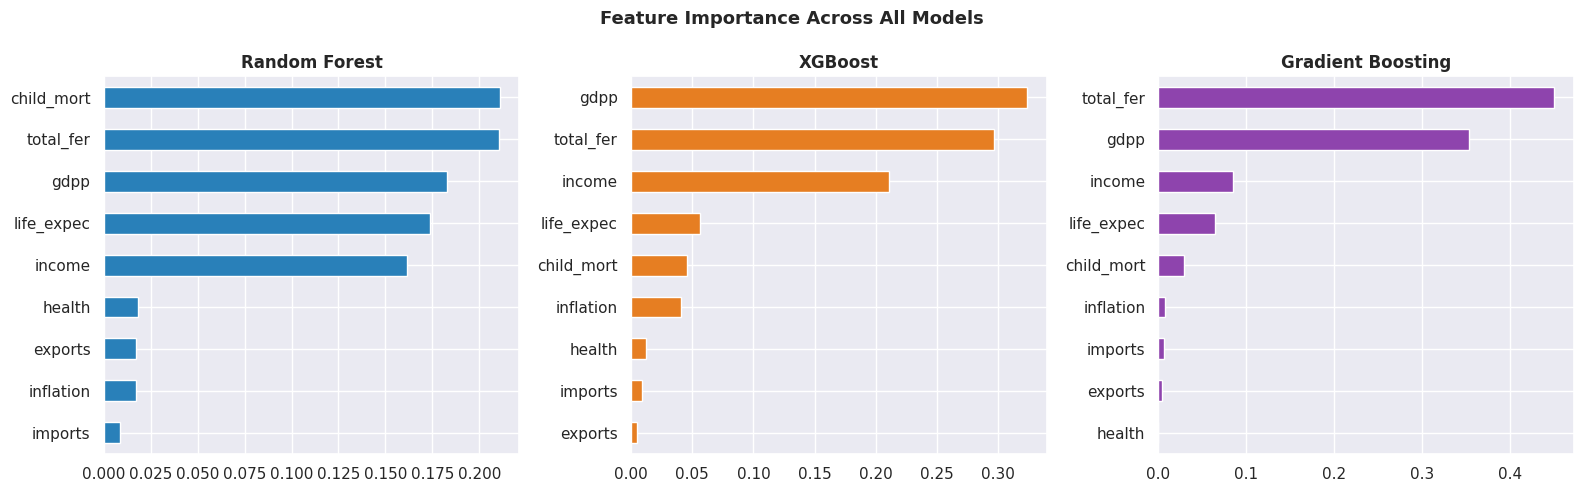

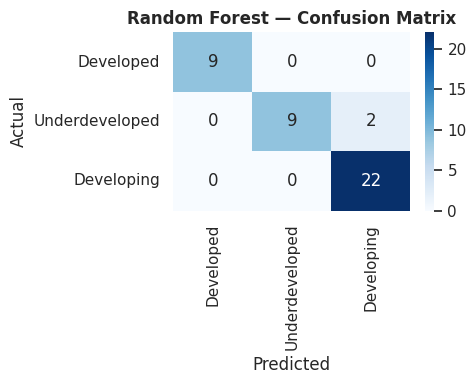

In [34]:
#Esemble Learning

y        = df['cluster']
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
X_tr, X_te, y_tr, y_te = __import__('sklearn.model_selection', fromlist=['train_test_split'])\
                          .train_test_split(X_sc, y, test_size=0.25, random_state=0, stratify=y)

models = {
    'Random Forest':      RandomForestClassifier(n_estimators=150, random_state=0),
    'XGBoost':            xgb.XGBClassifier(n_estimators=150, random_state=0, eval_metric='mlogloss', verbosity=0),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=150, random_state=0)
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_sc, y, cv=cv, scoring='accuracy')
    cv_scores[name] = scores
    model.fit(X_tr, y_tr)
    print(f"\n{name}  (CV acc: {scores.mean():.3f} ± {scores.std():.3f})")
    print(classification_report(y_te, model.predict(X_te),
          target_names=[stage_map[i] for i in sorted(stage_map)]))

# CV score comparison
plt.figure(figsize=(8, 4))
bp = plt.boxplot([cv_scores[n] for n in models], labels=models.keys(), patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.6))
plt.title("5-Fold CV Accuracy — Model Comparison", fontweight='bold')
plt.ylabel("Accuracy"); plt.ylim(0.7, 1.05)
plt.tight_layout(); plt.show()

# Feature importance — all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fi_colors = ['#2980b9','#e67e22','#8e44ad']
for ax, (name, model), color in zip(axes, models.items(), fi_colors):
    fi = pd.Series(model.feature_importances_, index=FEATS).sort_values()
    fi.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(name, fontweight='bold')
plt.suptitle("Feature Importance Across All Models", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Confusion matrix for best model (Random Forest)
rf_model = models['Random Forest']
cm = confusion_matrix(y_te, rf_model.predict(X_te))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[stage_map[i] for i in sorted(stage_map)],
            yticklabels=[stage_map[i] for i in sorted(stage_map)])
plt.title("Random Forest — Confusion Matrix", fontweight='bold')
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()



   CEO PRIORITY LIST — TOP 10 COUNTRIES NEEDING AID


,country,child_mort,income,life_expec,gdpp,total_fer,need_score
1,Haiti,208.0,"$1,500",32.100000,$662,3.330000,0.891
2,Central African Republic,149.0,$888,47.500000,$446,5.210000,0.755
3,Sierra Leone,160.0,"$1,220",55.000000,$399,5.200000,0.751
4,Chad,150.0,"$1,930",56.500000,$897,6.590000,0.719
5,Mali,137.0,"$1,870",59.500000,$708,6.550000,0.692
6,Niger,123.0,$814,58.800000,$348,7.490000,0.682
7,"Congo, Dem. Rep.",116.0,$609,57.500000,$334,6.540000,0.675
8,Guinea-Bissau,114.0,"$1,390",55.600000,$547,5.050000,0.669
9,Burkina Faso,116.0,"$1,430",57.900000,$575,5.870000,0.665
10,Lesotho,99.7,"$2,380",46.500000,"$1,170",3.300000,0.656


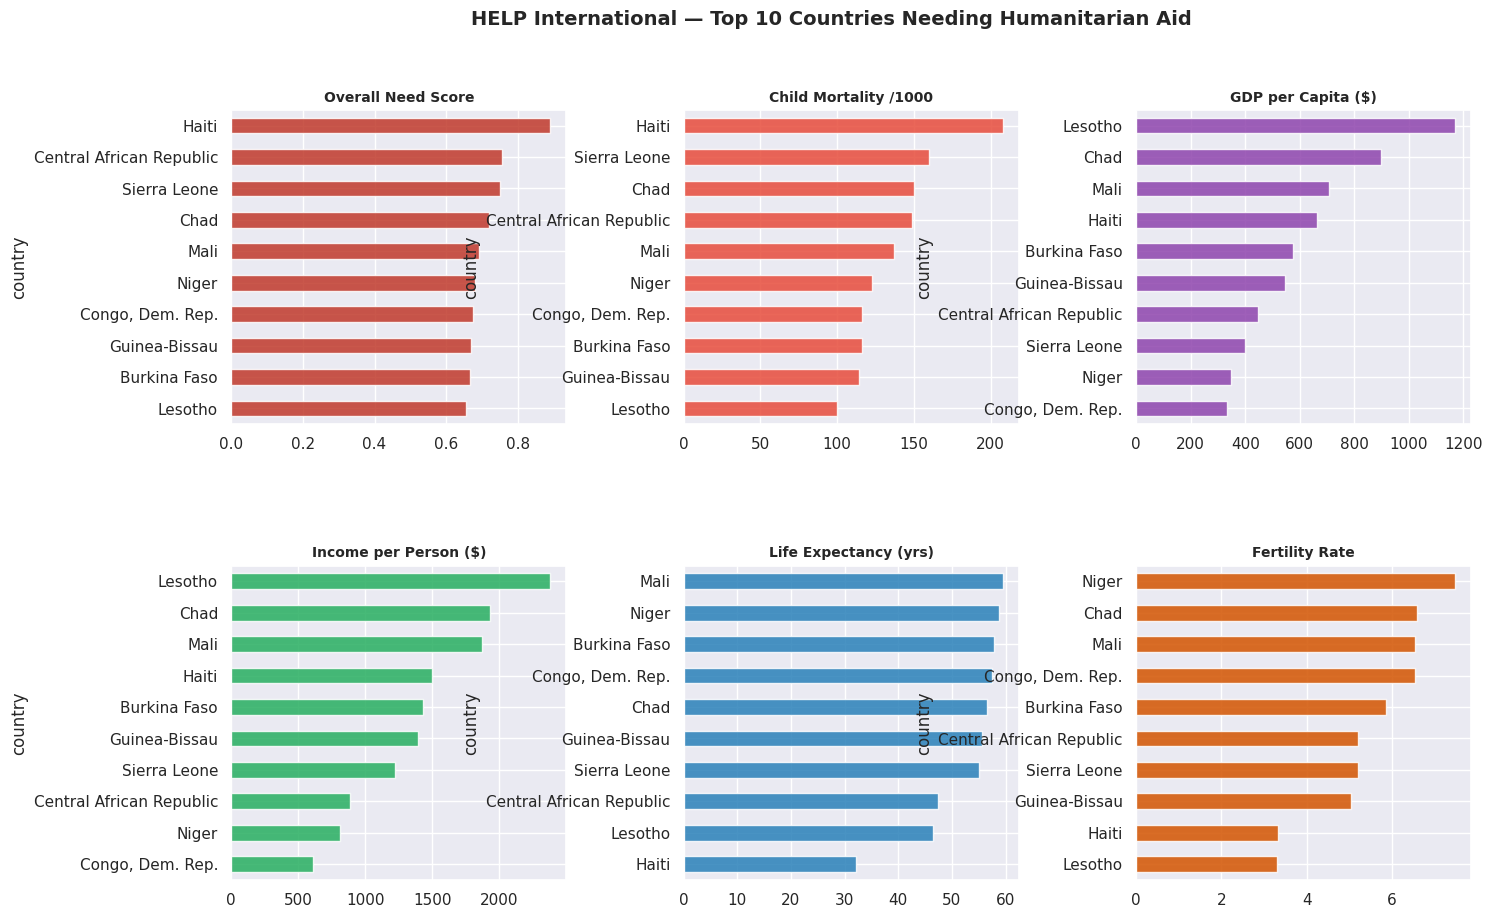

In [35]:
# SECTION 7 — CEO RECOMMENDATION
# =============================================================================

und = df[df['stage']=='Underdeveloped'].copy()

# Weighted composite score (child_mort & gdpp weighted more heavily)
und['need_score'] = (
    0.35 * (und['child_mort']  / und['child_mort'].max()) +
    0.25 * (1 - und['gdpp']       / und['gdpp'].max()) +
    0.20 * (1 - und['income']     / und['income'].max()) +
    0.20 * (1 - und['life_expec'] / und['life_expec'].max())
)

top10 = und.nlargest(10, 'need_score')[
    ['country','child_mort','income','life_expec','gdpp','total_fer','need_score']
].reset_index(drop=True)
top10.index += 1

print("\n" + "="*55)
print("   CEO PRIORITY LIST — TOP 10 COUNTRIES NEEDING AID")
print("="*55)
display(top10.style
        .background_gradient(subset=['need_score'], cmap='Reds')
        .background_gradient(subset=['child_mort'],  cmap='Reds')
        .background_gradient(subset=['life_expec'],  cmap='Greens')
        .format({'need_score': '{:.3f}', 'child_mort': '{:.1f}',
                 'gdpp': '${:,.0f}', 'income': '${:,.0f}'}))

# Dashboard-style final chart
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

panels = [
    (0, 0, 'need_score', 'Overall Need Score',       '#c0392b'),
    (0, 1, 'child_mort', 'Child Mortality /1000',    '#e74c3c'),
    (0, 2, 'gdpp',       'GDP per Capita ($)',        '#8e44ad'),
    (1, 0, 'income',     'Income per Person ($)',     '#27ae60'),
    (1, 1, 'life_expec', 'Life Expectancy (yrs)',     '#2980b9'),
    (1, 2, 'total_fer',  'Fertility Rate',            '#d35400'),
]
for r, c, col, title, color in panels:
    ax   = fig.add_subplot(gs[r, c])
    data = top10.set_index('country')[col].sort_values()
    data.plot(kind='barh', ax=ax, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel("")

fig.suptitle("HELP International — Top 10 Countries Needing Humanitarian Aid",
             fontsize=14, fontweight='bold')
plt.show()

In [36]:

df.to_csv('clustered_countries.csv', index=False)
top10.to_csv('ceo_priority_countries.csv', index=False)
print("\nFiles saved: clustered_countries.csv | ceo_priority_countries.csv")
print(f"\nFinal dataset columns: {list(df.columns)}")



Files saved: clustered_countries.csv | ceo_priority_countries.csv

Final dataset columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'cluster', 'stage', 'dbscan']
